# Demanda en urgencias del Gran Concepción: ETL y análisis descriptivo (avance)

**Objetivo del notebook:** producir el material numérico y gráfico de la presentación de avance (15-oct-2026): descripción de los datos, problemas de calidad, estadística descriptiva de la variable objetivo, figuras y baselines para la propuesta metodológica.

**Fuente:** Departamento de Estadísticas e Información de Salud (DEIS), MINSAL. *Atenciones de Urgencia*, archivos anuales 2023–2026 (repositorio DEIS, catálogo en datos.gob.cl) y diccionario de datos.

**Diseño temporal (por validar con los profesores)**

| Conjunto | Semanas (lunes–domingo, ISO) | Uso |
|---|---|---|
| Análisis y validación | 02-01-2023 a 22-12-2025 (156 semanas, años ISO 2023–2025) | EDA, baselines con validación de origen móvil |
| Test reservado | desde 29-12-2025 (2026 hasta la última semana completa) | No se mira en este notebook; se usa una sola vez al final y para el pronóstico del dashboard |

**Mapa del notebook → bloques de la presentación**

| Sección | Bloque |
|---|---|
| 1–3. Parámetros, descarga, ETL | 2. Datos (fuentes, integración, filtro) |
| 4. Tabla 1 | 2. Datos (unidad, n.º obs., período, variables) |
| 5–7. Tabla 2 y anexo de anomalías | 2. Datos (calidad) |
| 6, 8. Serie semanal y Tabla 3 | 3. Descriptivo (estadísticas del objetivo) |
| 9–12. Figuras 1 a 4 | 3. Descriptivo (gráficos) |
| 13–14. Anexos regional y día de la semana | 3. Hallazgos / anexo |
| 15. Tabla 4 | 3–4. Hallazgos que orientan el modelamiento |
| 16. Tabla 5 | 4. Propuesta metodológica (métricas, validación) |
| 18. Preguntas | 5. Próximos pasos / preguntas a los profesores |

**Aviso:** las celdas "Interpretación (grupo)" quedan pendientes a propósito; las interpretaciones las redacta el grupo.

## 1. Configuración y parámetros

In [1]:
import hashlib
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import acf

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas (relativas a la carpeta del repositorio)
DIR_RAW = Path("data/raw")
DIR_PROC = Path("data/processed")
DIR_FIG = Path("resultados/figuras")
DIR_TAB = Path("resultados/tablas")
for d in (DIR_RAW, DIR_PROC, DIR_FIG, DIR_TAB):
    d.mkdir(parents=True, exist_ok=True)

# Fuentes
ANIOS = [2023, 2024, 2025, 2026]
URL_ANIO = "https://repositoriodeis.minsal.cl/SistemaAtencionesUrgencia/AtencionesUrgencia{}.zip"
URL_DICC = ("https://datos.gob.cl/dataset/be2a922f-8ea4-4ebc-8828-0c713b702cd2/resource/"
            "79c05b22-391b-4dbd-a362-ba088fecabab/download/diccionario-de-datos-atencionesurgencia.xlsx")
RUTA_DICC = DIR_RAW / "diccionario-de-datos-atencionesurgencia.xlsx"
FORZAR_ETL = False   # True = volver a leer los zips aunque existan los parquet

# Diseño temporal: semanas lunes–domingo; la semana que toca 2026 ya es test
INICIO_TEST = pd.Timestamp("2026-01-01")
CORTE_TEST_SEMANA = INICIO_TEST - pd.Timedelta(days=INICIO_TEST.weekday())   # lunes 29-12-2025
ANIOS_EDA = [2023, 2024, 2025]   # años ISO

# Comunas del área metropolitana núcleo (filtro por código, no por nombre)
COMUNAS = {8101: "Concepción", 8102: "Coronel", 8103: "Chiguayante", 8107: "Penco",
           8108: "San Pedro de la Paz", 8110: "Talcahuano", 8112: "Hualpén"}
# Candidatas fuera por ahora (por validar): 8104 Florida, 8105 Hualqui, 8106 Lota, 8109 Santa Juana, 8111 Tomé.

# Establecimientos que cambiaron de código entre años (código antiguo → actual)
ID_EQUIVALENTE = {"19-912": "201018"}   # SAR Los Cerros: 19-912 en 2023, 201018 desde 2024

ID_OBJETIVO = 1        # SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA (provisional)
ID_RESP = 2            # TOTAL CAUSAS SISTEMA RESPIRATORIO
BANDAS = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]
COLUMNAS = ["IdEstablecimiento", "NEstablecimiento", "IdCausa", "GlosaCausa", "Total", *BANDAS, "fecha", "semana",
            "GLOSATIPOESTABLECIMIENTO", "GLOSATIPOATENCION", "GlosaTipoCampana", "CodigoRegion", "NombreRegion",
            "CodigoDependencia", "NombreDependencia", "CodigoComuna", "NombreComuna"]
HORIZONTE = 1          # semanas hacia adelante

FUENTE = "Fuente: DEIS-MINSAL, Atenciones de Urgencia (repositorio DEIS / datos.gob.cl). Elaboración propia."

# Paleta UdeC (laboratorio del curso); un color fijo por tipo y por año
NAVY, GREY, ORANGE, RED, TEAL = "#223c6a", "#a0a0a0", "#e69b0a", "#d21428", "#00a896"
COLOR_TIPO = {"Hospital": NAVY, "SAR": TEAL, "SAPU": ORANGE}
COLOR_ANIO = {2023: NAVY, 2024: TEAL, 2025: ORANGE}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
SEMANA_MES = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48]   # semana ISO aprox. del día 1 de cada mes

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e6e6", "axes.edgecolor": "#bbbbbb"})
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12})


def miles(x, _=None):
    """Formato de miles con punto (es-CL)."""
    return f"{x:,.0f}".replace(",", ".")


def corto(texto, n):
    return texto if len(texto) <= n else texto[:n].rstrip() + "…"


def eje_semanas(ax):
    """Eje x = semana ISO (1–52) rotulado con meses aproximados."""
    ax.set_xticks(SEMANA_MES, MESES)
    ax.set_xlim(0.5, 52.5)


def sombrear_invierno(ax):
    ax.axvspan(22, 35.5, color=GREY, alpha=0.15, lw=0)
    ax.text(28.75, 0.98, "Invierno (jun–ago)", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=8, color="#555555")


def etiquetas_finales(ax, finales, sep_frac=0.045):
    """Rotula cada línea en su extremo derecho, separando etiquetas que chocan."""
    lo, hi = ax.get_ylim()
    sep = sep_frac * (hi - lo)
    orden = sorted(finales.items(), key=lambda kv: kv[1])
    ys = []
    for _, y in orden:
        ys.append(max(y, ys[-1] + sep) if ys else y)
    desplaz = np.mean([y for _, y in orden]) - np.mean(ys)   # recentrar el grupo en los valores reales
    for (texto, _), y in zip(orden, ys):
        y += desplaz
        ax.text(52.6, y, texto, va="center", fontsize=9, color="#333333")


def nota_fuente(fig, extra=""):
    """Agrega la nota de fuente al pie de la figura (exigida por la rúbrica)."""
    fig.text(0.01, 0.005, FUENTE + (f" {extra}" if extra else ""), fontsize=7.5, color="#555555",
             ha="left", va="bottom")


def guardar_fig(fig, nombre, extra=""):
    nota_fuente(fig, extra)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(DIR_FIG / f"{nombre}.png", dpi=200, bbox_inches="tight", facecolor="white")


def guardar_tabla(tabla, nombre, index=True):
    tabla.to_csv(DIR_TAB / f"{nombre}.csv", index=index, encoding="utf-8-sig")

## 2. Descarga de los datos crudos y manifiesto

Baja los zips anuales del DEIS y el diccionario de datos solo si faltan. Los crudos **no se versionan** (cada zip pesa 25–50 MB y cada CSV ~1,6–1,9 GB); en su lugar se versiona `data/raw/README.md` con URL, tamaño, fecha y SHA-256 de cada archivo, para poder verificar que se usa la misma versión. El archivo del año en curso (2026) lo actualiza el DEIS a diario: el manifiesto deja registrada la foto usada.

In [2]:
def sha256(ruta):
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(1 << 20), b""):
            h.update(bloque)
    return h.hexdigest()


fuentes = {DIR_RAW / f"AtencionesUrgencia{a}.zip": URL_ANIO.format(a) for a in ANIOS}
fuentes[RUTA_DICC] = URL_DICC
for ruta, url in fuentes.items():
    if not ruta.exists():
        print("Descargando", url)
        urllib.request.urlretrieve(url, ruta)

manifiesto = pd.DataFrame([{
    "Archivo": r.name, "URL": u, "MB": round(r.stat().st_size / 1e6, 1),
    "Fecha de descarga": datetime.fromtimestamp(r.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    "SHA-256": sha256(r)} for r, u in fuentes.items()])

lineas = ["# Datos crudos (no versionados)", "",
          "Estos archivos no se suben a GitHub por su tamaño. `Trabajo.ipynb` (sección 2) los descarga si faltan "
          "y reescribe este manifiesto. Si el SHA-256 de un archivo no coincide, el DEIS publicó una versión nueva.", "",
          "| " + " | ".join(manifiesto.columns) + " |", "|" + "---|" * manifiesto.shape[1]]
lineas += ["| " + " | ".join(str(v) for v in fila) + " |" for fila in manifiesto.itertuples(index=False)]
lineas += ["", "- `AtencionesUrgencia2026.zip` es una foto del año en curso (el DEIS lo actualiza a diario).",
           "- `AtencionesUrgencia2024/` (si existe) es una descarga anterior ya descomprimida; no se usa "
           "(el ETL lee los zips directamente)."]
(DIR_RAW / "README.md").write_text("\n".join(lineas) + "\n", encoding="utf-8")
display(manifiesto.drop(columns="SHA-256"))

,Archivo,URL,MB,Fecha de descarga
0,AtencionesUrgencia2023.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,138.9,2026-10-05 23:46
1,AtencionesUrgencia2024.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,49.9,2026-10-05 23:46
2,AtencionesUrgencia2025.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,55.3,2026-10-05 23:46
3,AtencionesUrgencia2026.zip,https://repositoriodeis.minsal.cl/SistemaAtenc...,42.4,2026-10-05 23:46
4,diccionario-de-datos-atencionesurgencia.xlsx,https://datos.gob.cl/dataset/be2a922f-8ea4-4eb...,0.4,2026-10-05 23:46


## 3. ETL: lectura de los zips por bloques y filtro Gran Concepción

Se lee cada zip sin descomprimir, en bloques de 1 millón de filas, con `encoding="latin-1"` y `sep=";"`; `IdEstablecimiento` se fuerza a texto. Por año se verifica que las columnas sean las mismas. De cada bloque se guardan (a) las filas de las 7 comunas y (b) el total país por región y día de las causas 1 y 2 (para revisar la caída de junio a nivel nacional).

Armonización: el código antiguo de SAR Los Cerros se reemplaza por el actual y cada establecimiento recibe un nombre único (el más reciente), porque los nombres cambian de escritura entre años (p. ej. "SAPU-Lorenzo Arenas" / "SAPU Lorenzo Arenas").

El resultado se guarda en `data/processed/`; si ya existe y `FORZAR_ETL = False`, se carga desde ahí (segundos en vez de ~2 minutos).

In [3]:
RUTA_DIARIO = DIR_PROC / "urgencias_gc_diario.parquet"
RUTA_PAIS = DIR_PROC / "urgencias_pais_region_diario.parquet"
RUTA_PERFIL = DIR_PROC / "perfil_archivos.csv"

if FORZAR_ETL or not all(r.exists() for r in (RUTA_DIARIO, RUTA_PAIS, RUTA_PERFIL)):
    partes, pais, perfil = [], [], []
    for anio in ANIOS:
        filas, nan_comuna, causas = 0, 0, set()
        lector = pd.read_csv(DIR_RAW / f"AtencionesUrgencia{anio}.zip", sep=";", encoding="latin-1",
                             dtype={"IdEstablecimiento": str}, chunksize=1_000_000)
        for bloque in lector:
            assert list(bloque.columns) == COLUMNAS, f"{anio}: columnas distintas"
            filas += len(bloque)
            nan_comuna += int(bloque["CodigoComuna"].isna().sum())
            causas |= set(bloque["IdCausa"].unique().tolist())
            partes.append(bloque[bloque["CodigoComuna"].isin(list(COMUNAS))])
            pais.append(bloque[bloque["IdCausa"].isin([ID_OBJETIVO, ID_RESP])]
                        .groupby(["CodigoRegion", "NombreRegion", "fecha", "IdCausa"])["Total"].sum())
        perfil.append({"anio": anio, "filas_pais": filas, "codigo_comuna_vacio": nan_comuna,
                       "n_causas": len(causas), "causas": " ".join(map(str, sorted(causas)))})

    df = pd.concat(partes, ignore_index=True)
    df["CodigoComuna"] = df["CodigoComuna"].astype(int)
    df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")
    df["GlosaCausa"] = df["GlosaCausa"].str.strip()
    df["IdEstablecimiento"] = df["IdEstablecimiento"].replace(ID_EQUIVALENTE)
    df = df.sort_values(["fecha", "IdEstablecimiento", "IdCausa"], ignore_index=True)
    df["establecimiento"] = df.groupby("IdEstablecimiento")["NEstablecimiento"].transform("last")

    pais = pd.concat(pais).reset_index()
    pais["fecha"] = pd.to_datetime(pais["fecha"], format="%d/%m/%Y")
    pais["NombreRegion"] = pais.groupby("CodigoRegion")["NombreRegion"].transform("last")
    pais = pais.groupby(["CodigoRegion", "NombreRegion", "fecha", "IdCausa"], as_index=False)["Total"].sum()

    df.to_parquet(RUTA_DIARIO, index=False)
    pais.to_parquet(RUTA_PAIS, index=False)
    pd.DataFrame(perfil).to_csv(RUTA_PERFIL, index=False)

df = pd.read_parquet(RUTA_DIARIO)
pais = pd.read_parquet(RUTA_PAIS)
perfil = pd.read_csv(RUTA_PERFIL).set_index("anio")
df["anio"] = df["fecha"].dt.year

# Validaciones
pares = df[["CodigoComuna", "NombreComuna"]].drop_duplicates()
assert set(pares["CodigoComuna"]) == set(COMUNAS), "faltan o sobran comunas"
assert all(COMUNAS[c] == n for c, n in pares.itertuples(index=False)), pares
assert (df.groupby("IdEstablecimiento")[["GLOSATIPOESTABLECIMIENTO", "CodigoComuna"]].nunique().max() == 1).all(), \
    "un establecimiento cambia de tipo o comuna"

print(f"Filas Gran Concepción: {miles(len(df))} | {df['fecha'].min():%d-%m-%Y} a {df['fecha'].max():%d-%m-%Y} "
      f"| establecimientos: {df['IdEstablecimiento'].nunique()}")

Filas Gran Concepción: 1.433.632 | 01-01-2023 a 04-10-2026 | establecimientos: 27


## 4. Tabla 1 – Descripción de los datos

Para 2026 (test) solo se muestran conteos de estructura (filas, período, establecimientos), sin mirar los valores.

In [4]:
info_est = (df.groupby("IdEstablecimiento")
              .agg(establecimiento=("establecimiento", "last"), tipo=("GLOSATIPOESTABLECIMIENTO", "last"),
                   comuna=("NombreComuna", "last")))

def resumen_anio(a):
    d = df[df["anio"] == a]
    tipos = d.drop_duplicates("IdEstablecimiento")["GLOSATIPOESTABLECIMIENTO"].value_counts()
    return {
        "Filas (país)": miles(perfil.loc[a, "filas_pais"]),
        "Filas (Gran Concepción)": miles(len(d)),
        "Período": f"{d['fecha'].min():%d-%m-%Y} a {d['fecha'].max():%d-%m-%Y}",
        "Días": d["fecha"].nunique(),
        "Establecimientos": d["IdEstablecimiento"].nunique(),
        "Por tipo": ", ".join(f"{t} {n}" for t, n in tipos.items()),
        "Causas (IdCausa)": int(perfil.loc[a, "n_causas"]),
        "Uso": "Test (reservado)" if a >= INICIO_TEST.year else "Análisis y validación",
    }

tabla1 = pd.DataFrame({a: resumen_anio(a) for a in ANIOS})
tabla1.index.name = "Ítem"
tabla1["Común a todos los años"] = ""
tabla1.loc["Unidad de observación"] = ["Establecimiento × día × causa"] * len(ANIOS) + [""]
tabla1.loc["Variables principales"] = [""] * len(ANIOS) + [
    "Total (atenciones) y 5 bandas etarias; fecha; establecimiento, tipo, comuna; IdCausa/GlosaCausa"]
guardar_tabla(tabla1, "tabla1_descripcion_datos")
display(tabla1)

# Tabla 1b: días con registro por establecimiento y año
dias = df.pivot_table(index="IdEstablecimiento", columns="anio", values="fecha", aggfunc="nunique")
tabla1b = info_est.join(dias)
tabla1b["Nota"] = ""
for viejo, nuevo in ID_EQUIVALENTE.items():
    tabla1b.loc[nuevo, "Nota"] = f"Código {viejo} hasta 2023"
dias_eda = df[df["fecha"] < INICIO_TEST].groupby("IdEstablecimiento")["fecha"].nunique()
tabla1b["En las series"] = dias_eda.reindex(tabla1b.index).fillna(0) >= 0.95 * df.loc[df["fecha"] < INICIO_TEST, "fecha"].nunique()
tabla1b.loc[~tabla1b["En las series"], "Nota"] += " Sin cobertura en 2023–2025: fuera de las series"
tabla1b = tabla1b.sort_values(["tipo", "establecimiento"])
guardar_tabla(tabla1b, "tabla1b_establecimientos_por_anio")
display(tabla1b)

causas = (df.sort_values("fecha").groupby("IdCausa")
            .agg(GlosaCausa=("GlosaCausa", "last"), desde=("anio", "min"), hasta=("anio", "max")).reset_index())
guardar_tabla(causas, "anexo_causas", index=False)

,2023,2024,2025,2026,Común a todos los años
Ítem,,,,,
Filas (país),8.899.080,8.973.229,9.142.479,7.092.918,
Filas (Gran Concepción),378.760,380.400,380.010,294.462,
Período,01-01-2023 a 31-12-2023,01-01-2024 a 31-12-2024,01-01-2025 a 31-12-2025,01-01-2026 a 04-10-2026,
Días,365,366,365,277,
Establecimientos,26,26,26,27,
Por tipo,"SAPU 12, SAR 10, Hospital 4","SAPU 12, SAR 10, Hospital 4","SAPU 12, SAR 10, Hospital 4","SAPU 13, SAR 10, Hospital 4",
Causas (IdCausa),40,40,41,41,
Uso,Análisis y validación,Análisis y validación,Análisis y validación,Test (reservado),
Unidad de observación,Establecimiento × día × causa,Establecimiento × día × causa,Establecimiento × día × causa,Establecimiento × día × causa,


,establecimiento,tipo,comuna,2023,2024,2025,2026,Nota,En las series
IdEstablecimiento,,,,,,,,,
18-100,Hospital Clínico Regional Dr. Guillermo Grant ...,Hospital,Concepción,365.0,366.0,365.0,276.0,,True
19-100,Hospital Las Higueras (Talcahuano),Hospital,Talcahuano,365.0,366.0,365.0,276.0,,True
19-102,Hospital Penco Lirquén,Hospital,Penco,365.0,366.0,365.0,273.0,,True
18-105,Hospital San José de Coronel,Hospital,Coronel,365.0,366.0,365.0,274.0,,True
19-807,SAPU Alcalde Leocán Portus,SAPU,Talcahuano,360.0,362.0,365.0,271.0,,True
18-810,SAPU Juan Soto Fernández,SAPU,Concepción,365.0,366.0,365.0,277.0,,True
19-986,SAPU La Floresta,SAPU,Hualpén,365.0,366.0,364.0,268.0,,True
18-812,SAPU Lagunillas,SAPU,Coronel,365.0,366.0,365.0,277.0,,True
18-814,SAPU Leonera,SAPU,Chiguayante,365.0,366.0,365.0,277.0,,True


> **Interpretación (grupo):** _pendiente_

## 5. Tabla 2 – Calidad de datos (2023–2025)

Algunas causas son totales o subtotales de otras, por lo que **sumar causas duplica conteos**. Los chequeos se hacen por año sobre el período de análisis.

In [5]:
eda = df[df["fecha"] < INICIO_TEST]
piv = eda.pivot_table(index=["IdEstablecimiento", "fecha"], columns="IdCausa", values="Total", aggfunc="sum")
piv["anio"] = piv.index.get_level_values("fecha").year


def chequeos(a):
    d, p = eda[eda["anio"] == a], piv[piv["anio"] == a]
    dias_anio = pd.date_range(f"{a}-01-01", f"{a}-12-31").size
    faltan = dias_anio - d.groupby("IdEstablecimiento")["fecha"].nunique()
    cpd = d.groupby(["IdEstablecimiento", "fecha"])["IdCausa"].nunique()
    obj = d[d["IdCausa"] == ID_OBJETIVO]
    dif = p[34] - p[1]
    pct = lambda a_, b_: f"{100 * (a_ == b_).mean():.1f} %"
    return {
        "Duplicados (establecimiento, fecha, causa)": int(d.duplicated(["IdEstablecimiento", "fecha", "IdCausa"]).sum()),
        "Causas por establecimiento-día": f"{cpd.min()}–{cpd.max()}",
        "Establecimiento-días sin fila (n.º establecimientos)": f"{int(faltan.clip(lower=0).sum())} ({int((faltan > 0).sum())})",
        f"Días con objetivo (IdCausa {ID_OBJETIVO}) = 0": int((obj["Total"] == 0).sum()),
        "Filas con suma de bandas ≠ Total": int((d[BANDAS].sum(axis=1) != d["Total"]).sum()),
        "Negativos o NaN en Total/bandas": int((d[BANDAS + ["Total"]] < 0).sum().sum() + d[BANDAS + ["Total"]].isna().sum().sum()),
        "% días id 2 = suma ids 3,4,5,6,10,11": pct(p[2], p[[3, 4, 5, 6, 10, 11]].sum(axis=1)),
        "% días id 12 = suma ids 13–17": pct(p[12], p[[13, 14, 15, 16, 17]].sum(axis=1)),
        "% días id 1 = suma ids 2,12,18,21": pct(p[1], p[[2, 12, 18, 21]].sum(axis=1)),
        "id 34 − id 1: media; mín.; máx.": f"{dif.mean():.1f}; {dif.min():.0f}; {dif.max():.0f}",
        "CodigoComuna vacío (país)": miles(perfil.loc[a, "codigo_comuna_vacio"]),
    }


tratamiento = {
    "Duplicados (establecimiento, fecha, causa)": "Nada que eliminar",
    "Causas por establecimiento-día": "Grilla completa de causas cuando el día existe",
    "Establecimiento-días sin fila (n.º establecimientos)": "No se imputa; se registran días reportados por semana",
    f"Días con objetivo (IdCausa {ID_OBJETIVO}) = 0": "Se listan en el anexo de anomalías",
    "Filas con suma de bandas ≠ Total": "Bandas etarias consistentes",
    "Negativos o NaN en Total/bandas": "—",
    "% días id 2 = suma ids 3,4,5,6,10,11": "id 2 es subtotal: no sumar con sus componentes",
    "% días id 12 = suma ids 13–17": "id 12 es subtotal: no sumar con sus componentes",
    "% días id 1 = suma ids 2,12,18,21": "La jerarquía no cierra: preguntar a profesores / DEIS",
    "id 34 − id 1: media; mín.; máx.": "id 34 ≠ id 1: confirmar cuál es la demanda total",
    "CodigoComuna vacío (país)": "Filas sin comuna no entran al filtro",
}
tabla2 = pd.DataFrame({a: chequeos(a) for a in ANIOS_EDA})
tabla2["Tratamiento en el pipeline"] = pd.Series(tratamiento)
extra = pd.DataFrame({
    "Tratamiento en el pipeline": {
        "Cambio de código de establecimiento": "SAR Los Cerros: 19-912 (2023) → 201018; se unifican",
        "Nombres con distinta escritura entre años": "Se usa el nombre más reciente por código",
        "Semanas parciales en los bordes": "Se descartan (solo semanas lunes–domingo completas)",
        "IdEstablecimiento con tipos mixtos": "Se lee como texto",
        "Codificación del archivo": "latin-1 (no UTF-8)",
    }})
tabla2 = pd.concat([tabla2, extra])
tabla2.index.name = "Chequeo"
guardar_tabla(tabla2, "tabla2_calidad_datos")
display(tabla2.fillna(""))

,2023,2024,2025,Tratamiento en el pipeline
Chequeo,,,,
"Duplicados (establecimiento, fecha, causa)",0,0,0,Nada que eliminar
Causas por establecimiento-día,40–40,40–40,40–41,Grilla completa de causas cuando el día existe
Establecimiento-días sin fila (n.º establecimientos),21 (6),6 (3),1 (1),No se imputa; se registran días reportados por...
Días con objetivo (IdCausa 1) = 0,11,12,9,Se listan en el anexo de anomalías
Filas con suma de bandas ≠ Total,0,0,0,Bandas etarias consistentes
Negativos o NaN en Total/bandas,0,0,0,—
"% días id 2 = suma ids 3,4,5,6,10,11",100.0 %,100.0 %,100.0 %,id 2 es subtotal: no sumar con sus componentes
% días id 12 = suma ids 13–17,100.0 %,100.0 %,100.0 %,id 12 es subtotal: no sumar con sus componentes
"% días id 1 = suma ids 2,12,18,21",6.2 %,4.8 %,3.4 %,La jerarquía no cierra: preguntar a profesores...


> **Interpretación (grupo):** _pendiente_

## 6. Serie semanal por establecimiento

Se toman solo las filas `IdCausa == ID_OBJETIVO` (no se suman causas). Semana lunes–domingo identificada por su lunes y por año/semana ISO (cada año ISO 2023–2025 tiene 52 semanas). Se agrega el total respiratorio (id 2) y las bandas etarias. Se descartan las semanas parciales de los bordes y se separa el test (semanas desde el 29-12-2025).

In [6]:
def a_semanas(d):
    return d.assign(semana_inicio=d["fecha"] - pd.to_timedelta(d["fecha"].dt.weekday, unit="D"))

obj = a_semanas(df[df["IdCausa"] == ID_OBJETIVO])
sem = (obj.groupby(["IdEstablecimiento", "semana_inicio"])
          .agg(atenciones=("Total", "sum"), dias_reportados=("fecha", "nunique"), **{b: (b, "sum") for b in BANDAS})
          .reset_index())
resp = (a_semanas(df[df["IdCausa"] == ID_RESP]).groupby(["IdEstablecimiento", "semana_inicio"])["Total"].sum()
          .rename("atenciones_resp").reset_index())
sem = sem.merge(resp, on=["IdEstablecimiento", "semana_inicio"], how="left").join(info_est, on="IdEstablecimiento")

# Solo semanas completas dentro del rango de datos
completa = (sem["semana_inicio"] >= df["fecha"].min()) & (sem["semana_inicio"] + pd.Timedelta(days=6) <= df["fecha"].max())
sem = sem[completa].reset_index(drop=True)
iso = sem["semana_inicio"].dt.isocalendar()
sem["anio_iso"], sem["semana_iso"] = iso["year"].astype(int), iso["week"].astype(int)
sem["conjunto"] = np.where(sem["semana_inicio"] < CORTE_TEST_SEMANA, "analisis", "test")

# Universo de series: establecimientos con cobertura en 2023–2025
en_series = tabla1b.index[tabla1b["En las series"]]
sem_eda = sem[(sem["conjunto"] == "analisis") & sem["IdEstablecimiento"].isin(en_series)].copy()

semanas_eda = pd.date_range(sem_eda["semana_inicio"].min(), sem_eda["semana_inicio"].max(), freq="W-MON")
assert len(semanas_eda) == 156 and sem_eda["semana_inicio"].nunique() == 156, "faltan semanas"
assert sem_eda["semana_inicio"].max() + pd.Timedelta(days=6) < INICIO_TEST, "el análisis toca el test"
obj_ok = obj[obj["IdEstablecimiento"].isin(en_series) & obj["semana_inicio"].isin(semanas_eda)]
assert sem_eda["atenciones"].sum() == obj_ok["Total"].sum(), "semanal ≠ suma diaria"

tot = sem_eda.groupby(["semana_inicio", "anio_iso", "semana_iso"])[["atenciones", "atenciones_resp"] + BANDAS].sum() \
             .reset_index().set_index("semana_inicio")
Y = sem_eda.pivot(index="IdEstablecimiento", columns="semana_inicio", values="atenciones")   # establecimiento × semana

print(f"Análisis: {len(semanas_eda)} semanas ({semanas_eda[0]:%d-%m-%Y} a {semanas_eda[-1] + pd.Timedelta(days=6):%d-%m-%Y}) "
      f"× {Y.shape[0]} establecimientos | celdas vacías: {int(Y.isna().sum().sum())}")
print(f"Test reservado: {sem.loc[sem['conjunto'] == 'test', 'semana_inicio'].nunique()} semanas completas "
      f"(desde {CORTE_TEST_SEMANA:%d-%m-%Y})")
print(f"Establecimiento-semanas con < 7 días reportados (análisis): {(sem_eda['dias_reportados'] < 7).sum()} de {len(sem_eda)}")

Análisis: 156 semanas (02-01-2023 a 28-12-2025) × 26 establecimientos | celdas vacías: 0
Test reservado: 40 semanas completas (desde 29-12-2025)
Establecimiento-semanas con < 7 días reportados (análisis): 21 de 4056


## 7. Anexo – Anomalías (2023–2025)

- **Días con objetivo = 0** (posible cierre o falta de registro).
- **Semanas anómalas**: atenciones fuera del 50 %–150 % de la mediana móvil centrada de 9 semanas del mismo establecimiento, o con menos de 7 días reportados.

Se **marcan, no se borran**: cómo tratarlas en el modelo (excluir, imputar o dejar) es una decisión pendiente.

In [7]:
ceros = (eda[(eda["IdCausa"] == ID_OBJETIVO) & (eda["Total"] == 0)]
           [["IdEstablecimiento", "establecimiento", "fecha"]].sort_values(["establecimiento", "fecha"]))

ref = Y.T.rolling(9, center=True, min_periods=5).median().T
razon = Y / ref
marca = (razon < 0.5) | (razon > 1.5)
dias_rep = sem_eda.pivot(index="IdEstablecimiento", columns="semana_inicio", values="dias_reportados")
marca_total = marca | (dias_rep < 7)

anomalias = (pd.DataFrame({"atenciones": Y.stack(), "mediana_9_sem": ref.stack().round(0), "razon": razon.stack().round(2),
                           "dias_reportados": dias_rep.stack(), "marca": marca_total.stack()})
               .query("marca").drop(columns="marca").reset_index()
               .join(info_est[["establecimiento", "tipo"]], on="IdEstablecimiento"))
anomalias["motivo"] = np.select([anomalias["dias_reportados"] < 7, anomalias["razon"] < 0.5],
                                ["< 7 días reportados", "< 50 % de la mediana"], "> 150 % de la mediana")
anomalias = anomalias[["establecimiento", "tipo", "semana_inicio", "atenciones", "mediana_9_sem", "razon",
                       "dias_reportados", "motivo"]].sort_values(["establecimiento", "semana_inicio"])

guardar_tabla(ceros, "anexo_dias_objetivo_cero", index=False)
guardar_tabla(anomalias, "anexo_semanas_anomalas", index=False)
print(f"Días con objetivo = 0: {len(ceros)} | semanas anómalas: {len(anomalias)} de {Y.size} "
      f"({100 * len(anomalias) / Y.size:.1f} %)")
display(anomalias)
display(ceros.groupby("establecimiento")["fecha"].agg(["count", "min", "max"]))

Días con objetivo = 0: 32 | semanas anómalas: 22 de 4056 (0.5 %)


,establecimiento,tipo,semana_inicio,atenciones,mediana_9_sem,razon,dias_reportados,motivo
17,SAPU Alcalde Leocán Portus,SAPU,2023-01-16,140,429.0,0.33,5,< 7 días reportados
18,SAPU Alcalde Leocán Portus,SAPU,2023-02-20,286,429.0,0.67,4,< 7 días reportados
19,SAPU Alcalde Leocán Portus,SAPU,2024-04-08,578,679.0,0.85,6,< 7 días reportados
20,SAPU Alcalde Leocán Portus,SAPU,2024-10-07,422,709.0,0.60,4,< 7 días reportados
21,SAPU La Floresta,SAPU,2025-06-30,336,518.0,0.65,6,< 7 días reportados
16,SAPU Paulina Avendaño Pereda,SAPU,2024-10-21,328,486.0,0.67,6,< 7 días reportados
0,SAPU Yobilo,SAPU,2023-02-06,398,461.0,0.86,6,< 7 días reportados
1,SAPU Yobilo,SAPU,2023-04-10,542,643.0,0.84,6,< 7 días reportados
2,SAPU Yobilo,SAPU,2023-08-07,522,522.0,1.00,6,< 7 días reportados
3,SAPU Yobilo,SAPU,2023-08-14,349,539.0,0.65,5,< 7 días reportados


,count,min,max
establecimiento,,,
Hospital Penco Lirquén,3,2024-03-28,2025-04-02
SAPU Alcalde Leocán Portus,8,2023-01-17,2025-07-30
SAPU La Floresta,3,2023-02-25,2025-06-23
SAPU Lorenzo Arenas,1,2023-06-18,2023-06-18
SAPU Paulina Avendaño Pereda,5,2024-10-04,2025-10-28
SAPU Santa Sabina,2,2023-01-01,2024-01-01
SAPU Talcahuano Sur,1,2023-02-24,2023-02-24
SAPU Yobilo,1,2025-03-10,2025-03-10
SAR Hualpencillo,4,2023-01-19,2024-10-13


> **Interpretación (grupo):** _pendiente_

## 8. Tabla 3 – Estadística descriptiva de la variable objetivo (atenciones semanales, 2023–2025)

In [8]:
def describir(s):
    s = s.dropna()
    return pd.Series({"semanas": s.size, "media": s.mean(), "mediana": s.median(), "desv": s.std(),
                      "min": s.min(), "max": s.max(), "CV_%": 100 * s.std() / s.mean(), "asimetria": s.skew()})

filas = {"Total Gran Concepción 2023–2025": describir(tot["atenciones"])}
for a in ANIOS_EDA:
    filas[f"Total Gran Concepción {a}"] = describir(tot.loc[tot["anio_iso"] == a, "atenciones"])
por_tipo_sem = sem_eda.groupby(["tipo", "semana_inicio"])["atenciones"].sum()
for t in por_tipo_sem.index.get_level_values(0).unique():
    filas[f"Tipo {t} (suma, 2023–2025)"] = describir(por_tipo_sem.loc[t])
tabla3 = pd.DataFrame(filas).T.round(1)
tabla3.index.name = "Serie"
guardar_tabla(tabla3, "tabla3_estadistica_objetivo")
display(tabla3)

# Tabla 3b: media semanal por establecimiento y año
tabla3b = sem_eda.pivot_table(index="IdEstablecimiento", columns="anio_iso", values="atenciones", aggfunc="mean")
tabla3b["var_%_2023_2025"] = 100 * (tabla3b[2025] / tabla3b[2023] - 1)
tabla3b["CV_%"] = 100 * Y.std(axis=1) / Y.mean(axis=1)
tabla3b = tabla3b.join(info_est).set_index(["establecimiento", "tipo", "comuna"])
tabla3b = tabla3b.round(1).sort_values(2025, ascending=False)
guardar_tabla(tabla3b, "tabla3b_media_semanal_establecimiento")
display(tabla3b)

,semanas,media,mediana,desv,min,max,CV_%,asimetria
Serie,,,,,,,,
Total Gran Concepción 2023–2025,156.0,23171.9,23846.5,2980.8,16306.0,28953.0,12.9,-0.4
Total Gran Concepción 2023,52.0,22886.2,23403.0,3317.2,17336.0,28953.0,14.5,-0.0
Total Gran Concepción 2024,52.0,23374.2,24830.0,3044.2,16306.0,27130.0,13.0,-0.8
Total Gran Concepción 2025,52.0,23255.2,23880.0,2569.2,18619.0,26874.0,11.0,-0.5
"Tipo Hospital (suma, 2023–2025)",156.0,6184.0,6245.5,584.9,4737.0,7279.0,9.5,-0.2
"Tipo SAPU (suma, 2023–2025)",156.0,7324.4,7671.5,1335.4,4492.0,9946.0,18.2,-0.4
"Tipo SAR (suma, 2023–2025)",156.0,9663.5,9916.0,1165.5,7077.0,12236.0,12.1,-0.4


,,,2023,2024,2025,var_%_2023_2025,CV_%
establecimiento,tipo,comuna,,,,,
Hospital Clínico Regional Dr. Guillermo Grant Benavente (Concepción),Hospital,Concepción,1953.4,1912.2,2185.6,11.9,11.3
Hospital Las Higueras (Talcahuano),Hospital,Talcahuano,1857.3,1912.9,1999.6,7.7,9.1
SAR Chiguayante,SAR,Chiguayante,1012.8,1720.7,1678.5,65.7,25.2
Hospital San José de Coronel,Hospital,Coronel,1614.8,1508.7,1351.4,-16.3,14.8
SAR Hualpencillo,SAR,Hualpén,1257.1,1259.8,1278.7,1.7,11.5
SAR Tucapel,SAR,Concepción,950.3,1151.9,1202.3,26.5,17.0
SAPU Lagunillas,SAPU,Coronel,949.0,1032.5,1088.4,14.7,17.5
SAR Carlos Pinto Fierro,SAR,Coronel,905.2,942.0,914.4,1.0,15.8
SAR San Pedro,SAR,San Pedro de la Paz,888.7,891.4,878.9,-1.1,13.9


> **Interpretación (grupo):** _pendiente_

## 9. Figura 1 – Atenciones semanales totales por año

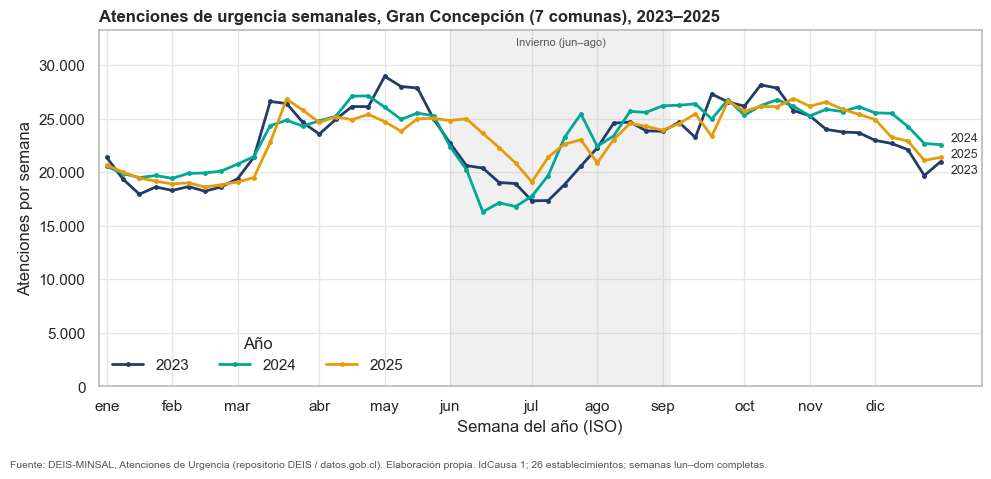

,media,semana máx.,máx.,semana mín.,mín.,índice mín. (100 = media)
año,,,,,,
2023,22886,01-05,28953,03-07,17336,76
2024,23374,22-04,27130,10-06,16306,70
2025,23255,20-10,26874,10-02,18619,80


In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sombrear_invierno(ax)
finales = {}
for a in ANIOS_EDA:
    s = tot[tot["anio_iso"] == a].set_index("semana_iso")["atenciones"]
    ax.plot(s.index, s.values, color=COLOR_ANIO[a], lw=2, marker="o", ms=2.5, label=str(a))
    finales[str(a)] = s.iloc[-1]
ax.set_ylim(0, tot["atenciones"].max() * 1.15)
etiquetas_finales(ax, finales)
ax.yaxis.set_major_formatter(FuncFormatter(miles))
eje_semanas(ax)
ax.set_xlim(0.5, 54.5)
ax.set_ylabel("Atenciones por semana")
ax.set_xlabel("Semana del año (ISO)")
ax.legend(title="Año", loc="lower left", frameon=False, ncols=3)
ax.set_title("Atenciones de urgencia semanales, Gran Concepción (7 comunas), 2023–2025", loc="left")
guardar_fig(fig, "fig1_atenciones_semanales_por_anio",
            f"IdCausa {ID_OBJETIVO}; {Y.shape[0]} establecimientos; semanas lun–dom completas.")
plt.show()

res = []
for a in ANIOS_EDA:
    s = tot[tot["anio_iso"] == a]["atenciones"]
    res.append({"año": a, "media": round(s.mean()), "semana máx.": f"{s.idxmax():%d-%m}", "máx.": s.max(),
                "semana mín.": f"{s.idxmin():%d-%m}", "mín.": s.min(), "índice mín. (100 = media)": round(100 * s.min() / s.mean())})
display(pd.DataFrame(res).set_index("año"))

> **Interpretación (grupo):** _pendiente_

## 10. Figura 2 – Peso de las causas respiratorias por año

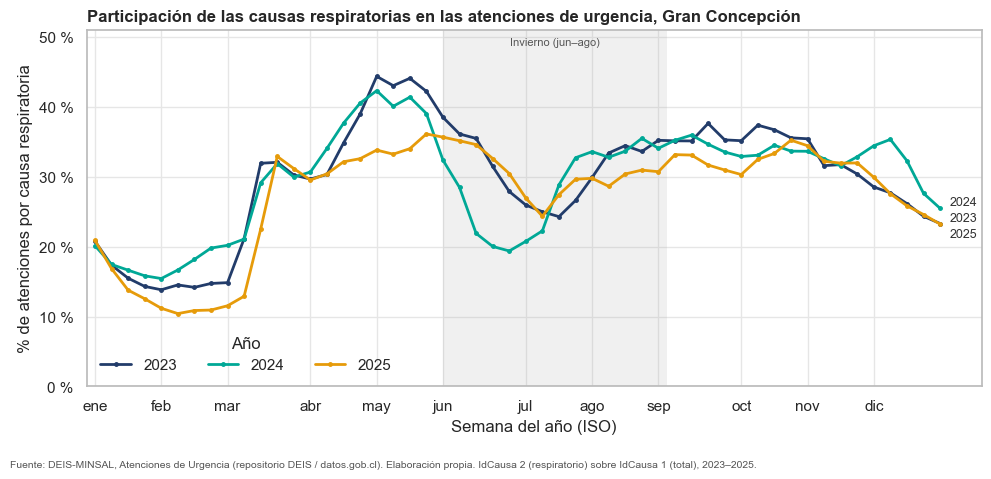

,mean,min,max,semana del máx.
anio_iso,,,,
2023,29.8,13.8,44.4,01-05
2024,29.5,15.4,42.3,29-04
2025,27.5,10.4,36.1,19-05


Correlación (Pearson) respiratorias vs total semanal: 0.92


In [10]:
assert (piv[ID_RESP] <= piv[ID_OBJETIVO]).all(), "el subtotal respiratorio supera al total"
tot["pct_resp"] = 100 * tot["atenciones_resp"] / tot["atenciones"]

fig, ax = plt.subplots(figsize=(10, 4.8))
sombrear_invierno(ax)
finales = {}
for a in ANIOS_EDA:
    s = tot[tot["anio_iso"] == a].set_index("semana_iso")["pct_resp"]
    ax.plot(s.index, s.values, color=COLOR_ANIO[a], lw=2, marker="o", ms=2.5, label=str(a))
    finales[str(a)] = s.iloc[-1]
ax.set_ylim(0, tot["pct_resp"].max() * 1.15)
etiquetas_finales(ax, finales)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f} %"))
eje_semanas(ax)
ax.set_xlim(0.5, 54.5)
ax.set_ylabel("% de atenciones por causa respiratoria")
ax.set_xlabel("Semana del año (ISO)")
ax.legend(title="Año", loc="lower left", frameon=False, ncols=3)
ax.set_title("Participación de las causas respiratorias en las atenciones de urgencia, Gran Concepción", loc="left")
guardar_fig(fig, "fig2_participacion_respiratoria_por_anio",
            f"IdCausa {ID_RESP} (respiratorio) sobre IdCausa {ID_OBJETIVO} (total), 2023–2025.")
plt.show()

resumen_resp = tot.groupby("anio_iso")["pct_resp"].agg(["mean", "min", "max"]).round(1)
resumen_resp["semana del máx."] = tot.groupby("anio_iso")["pct_resp"].idxmax().dt.strftime("%d-%m")
display(resumen_resp)
print(f"Correlación (Pearson) respiratorias vs total semanal: {tot['atenciones_resp'].corr(tot['atenciones']):.2f}")

> **Interpretación (grupo):** _pendiente_

## 11. Figura 3 – Establecimientos según atenciones semanales medias (2025)

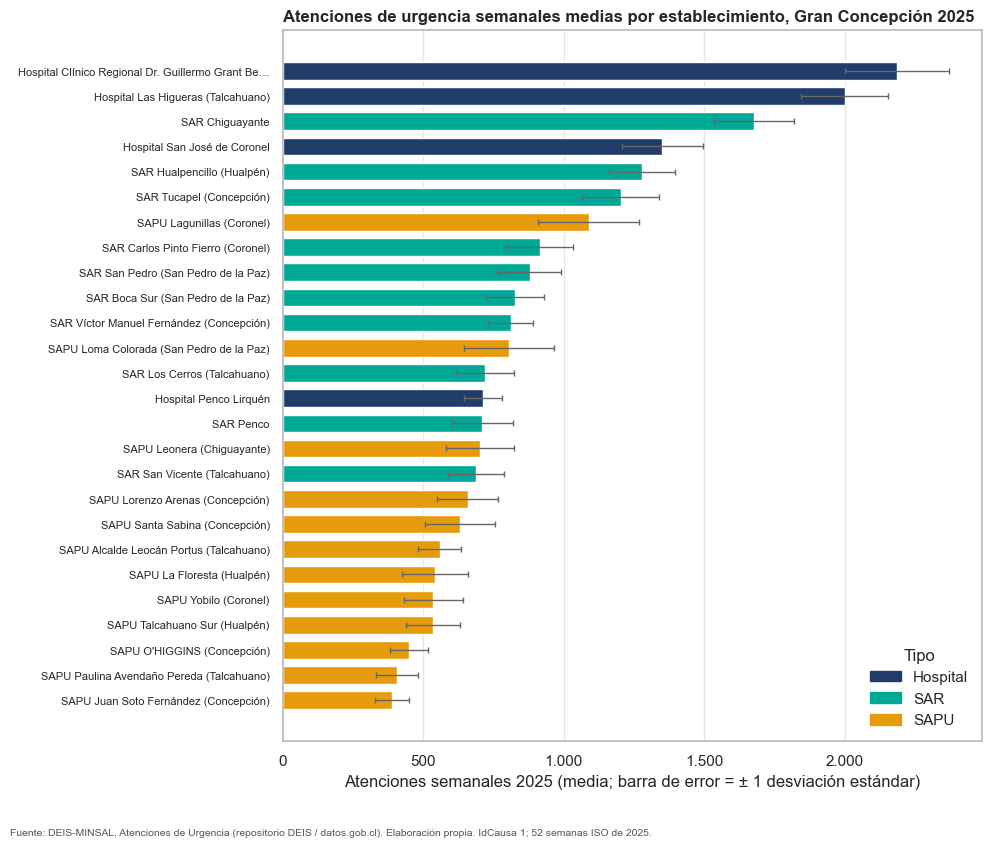

Los 5 mayores concentran el 36.5 % de las atenciones de 2025; establecimientos para llegar al 80 %: 18 de 26


In [11]:
ultimo = max(ANIOS_EDA)
Y_ult = Y.loc[:, tot.index[tot["anio_iso"] == ultimo]]
rank = Y_ult.agg(["mean", "std"], axis=1).join(info_est).sort_values("mean")
etiqueta = [corto(e, 48) + ("" if c in e else f" ({c})") for e, c in zip(rank["establecimiento"], rank["comuna"])]

fig, ax = plt.subplots(figsize=(10, 8.5))
ax.barh(etiqueta, rank["mean"], color=[COLOR_TIPO.get(t, GREY) for t in rank["tipo"]], height=0.7,
        xerr=rank["std"], error_kw={"ecolor": "#666666", "elinewidth": 1, "capsize": 2})
ax.xaxis.set_major_formatter(FuncFormatter(miles))
ax.set_xlabel(f"Atenciones semanales {ultimo} (media; barra de error = ± 1 desviación estándar)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
ax.legend(handles=[Patch(color=c, label=t) for t, c in COLOR_TIPO.items()], title="Tipo", loc="lower right", frameon=False)
ax.set_title(f"Atenciones de urgencia semanales medias por establecimiento, Gran Concepción {ultimo}", loc="left")
guardar_fig(fig, "fig3_ranking_establecimientos", f"IdCausa {ID_OBJETIVO}; 52 semanas ISO de {ultimo}.")
plt.show()

top = rank.sort_values("mean", ascending=False)
cuota = 100 * top["mean"].cumsum() / top["mean"].sum()
print(f"Los 5 mayores concentran el {cuota.iloc[4]:.1f} % de las atenciones de {ultimo}; "
      f"establecimientos para llegar al 80 %: {int((cuota < 80).sum()) + 1} de {len(top)}")

> **Interpretación (grupo):** _pendiente_

## 12. Figura 4 – Mapa de calor establecimiento × semana (índice 100 = media 2023–2025 del establecimiento)

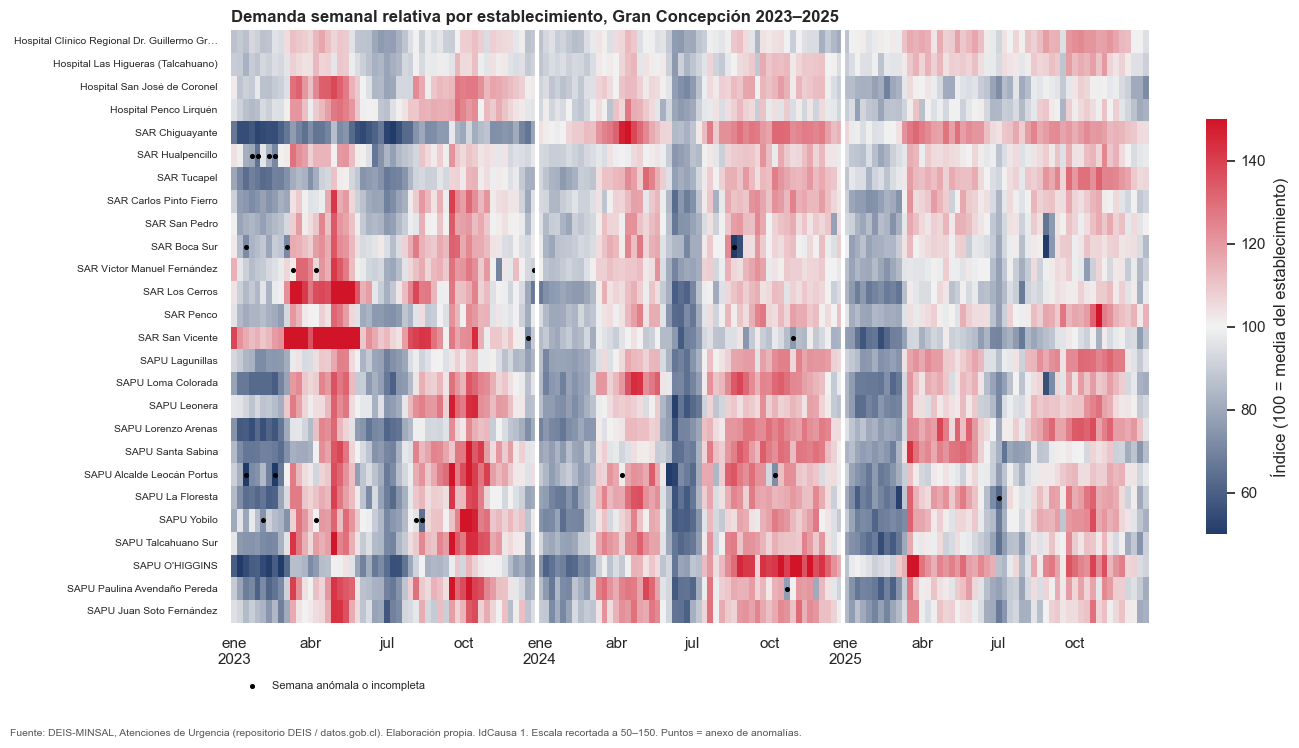

In [12]:
orden = rank.assign(t=rank["tipo"].map({t: k for k, t in enumerate(COLOR_TIPO)})) \
            .sort_values(["t", "mean"], ascending=[True, False]).index
indice = Y.loc[orden].div(Y.loc[orden].mean(axis=1), axis=0) * 100
cmap = LinearSegmentedColormap.from_list("div", [NAVY, "#f2f2f2", RED])

fig, ax = plt.subplots(figsize=(14, 7.5))
sns.heatmap(indice, cmap=cmap, vmin=50, vmax=150, center=100, ax=ax, linewidths=0,
            cbar_kws={"label": "Índice (100 = media del establecimiento)", "shrink": 0.7})
semanas = indice.columns
iso_cols = tot.loc[semanas, ["anio_iso", "semana_iso"]]
for k in np.where(iso_cols["semana_iso"].values == 1)[0][1:]:
    ax.axvline(k, color="white", lw=3)
pos = [k for k, w in enumerate(iso_cols["semana_iso"]) if w in (1, 14, 27, 40)]
ax.set_xticks([p + 0.5 for p in pos],
              [f"{MESES[SEMANA_MES.index(iso_cols['semana_iso'].iloc[p])]}" +
               (f"\n{iso_cols['anio_iso'].iloc[p]}" if iso_cols["semana_iso"].iloc[p] == 1 else "") for p in pos],
              rotation=0)
ax.set_yticks(np.arange(len(orden)) + 0.5, [corto(info_est.loc[i, "establecimiento"], 42) for i in orden], fontsize=7.5)
filas_m, cols_m = np.where(marca_total.loc[orden, semanas].values)
ax.scatter(cols_m + 0.5, filas_m + 0.5, s=7, color="black", marker="o", label="Semana anómala o incompleta")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), frameon=False, fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Demanda semanal relativa por establecimiento, Gran Concepción 2023–2025", loc="left")
guardar_fig(fig, "fig4_heatmap_indice_semanal",
            f"IdCausa {ID_OBJETIVO}. Escala recortada a 50–150. Puntos = anexo de anomalías.")
plt.show()

> **Interpretación (grupo):** _pendiente_

## 13. Anexo – ¿La caída de junio–julio es solo del Gran Concepción?

Por región y año ISO: índice de atenciones de las semanas ISO 24–27 (aprox. mediados de junio a mediados de julio; 100 = media del año) y % respiratorio en las semanas 16–21 (abril–mayo) frente a 24–27.

In [13]:
p = a_semanas(pais[pais["fecha"] < INICIO_TEST])
p = p[(p["semana_inicio"] >= semanas_eda[0]) & (p["semana_inicio"] <= semanas_eda[-1])]
p = p.pivot_table(index=["NombreRegion", "semana_inicio"], columns="IdCausa", values="Total", aggfunc="sum").reset_index()
iso_p = p["semana_inicio"].dt.isocalendar()
p["anio_iso"], p["semana_iso"] = iso_p["year"].astype(int), iso_p["week"].astype(int)
nac = p.groupby(["semana_inicio", "anio_iso", "semana_iso"])[[ID_OBJETIVO, ID_RESP]].sum().reset_index()
nac["NombreRegion"] = "PAÍS"
p = pd.concat([p, nac], ignore_index=True)


def indicadores(g):
    jun = g["semana_iso"].between(24, 27)
    abr = g["semana_iso"].between(16, 21)
    return pd.Series({"indice_jun_jul": 100 * g.loc[jun, ID_OBJETIVO].mean() / g[ID_OBJETIVO].mean(),
                      "resp_abr_may_%": 100 * g.loc[abr, ID_RESP].sum() / g.loc[abr, ID_OBJETIVO].sum(),
                      "resp_jun_jul_%": 100 * g.loc[jun, ID_RESP].sum() / g.loc[jun, ID_OBJETIVO].sum()})


anexo_reg = (p.groupby(["NombreRegion", "anio_iso"])[[ID_OBJETIVO, ID_RESP, "semana_iso"]].apply(indicadores)
               .unstack("anio_iso").round(0))
anexo_reg.columns = [f"{m} {a}" for m, a in anexo_reg.columns]
anexo_reg = anexo_reg[[f"{m} {a}" for m in ["indice_jun_jul", "resp_abr_may_%", "resp_jun_jul_%"] for a in ANIOS_EDA]]
guardar_tabla(anexo_reg, "anexo_caida_junio_regiones")
display(anexo_reg)

,indice_jun_jul 2023,indice_jun_jul 2024,indice_jun_jul 2025,resp_abr_may_% 2023,resp_abr_may_% 2024,resp_abr_may_% 2025,resp_jun_jul_% 2023,resp_jun_jul_% 2024,resp_jun_jul_% 2025
NombreRegion,,,,,,,,,
De Aisén del Gral. C. Ibáñez del Campo,92.0,87.0,102.0,28.0,33.0,23.0,31.0,22.0,30.0
De Antofagasta,92.0,99.0,105.0,42.0,40.0,34.0,35.0,34.0,35.0
De Arica y Parinacota,91.0,101.0,104.0,41.0,34.0,36.0,31.0,33.0,32.0
De Atacama,92.0,86.0,90.0,45.0,45.0,34.0,39.0,30.0,32.0
De Coquimbo,87.0,84.0,93.0,41.0,40.0,31.0,30.0,24.0,27.0
De La Araucanía,87.0,80.0,93.0,37.0,37.0,27.0,30.0,20.0,27.0
De Los Lagos,91.0,88.0,91.0,37.0,33.0,32.0,36.0,30.0,29.0
De Los Ríos,88.0,80.0,89.0,37.0,35.0,32.0,34.0,25.0,28.0
De Magallanes y de La Antártica Chilena,81.0,91.0,96.0,40.0,37.0,34.0,31.0,34.0,28.0


> **Interpretación (grupo):** _pendiente_

## 14. Anexo – Distribución por día de la semana (2023–2025)

In [14]:
dias_sem = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
o = eda[(eda["IdCausa"] == ID_OBJETIVO) & eda["IdEstablecimiento"].isin(en_series)]
o = o.assign(dia=o["fecha"].dt.dayofweek)
anexo_dia = o.pivot_table(index="dia", columns="GLOSATIPOESTABLECIMIENTO", values="Total", aggfunc="sum")
anexo_dia["Total"] = anexo_dia.sum(axis=1)
anexo_dia = (100 * anexo_dia / anexo_dia.sum()).round(1)
anexo_dia.index = dias_sem
anexo_dia.index.name = "día"
guardar_tabla(anexo_dia, "anexo_dia_semana")
display(anexo_dia)

GLOSATIPOESTABLECIMIENTO,Hospital,SAPU,SAR,Total
día,,,,
lun,16.2,15.4,14.5,15.2
mar,15.7,14.5,13.9,14.5
mié,15.3,13.7,13.7,14.1
jue,15.0,13.1,13.0,13.6
vie,14.4,12.2,12.8,13.1
sáb,11.8,14.9,15.6,14.4
dom,11.6,16.1,16.5,15.1


> **Interpretación (grupo):** _pendiente_

## 15. Tabla 4 – Dependencia temporal y relación entre bandas etarias

Autocorrelación del total semanal (rezagos 1–8 y 52 = misma semana del año anterior) y mediana entre establecimientos; Spearman entre bandas etarias (establecimiento-semana). Justifica rezagos y variables estacionales, y advierte colinealidad.

In [15]:
rezagos = [*range(1, 9), 52]
acf_total = acf(tot["atenciones"], nlags=52)
acf_est = pd.DataFrame({i: acf(s, nlags=52, missing="drop") for i, s in Y.iterrows()})
tabla4a = pd.DataFrame({"rezago_semanas": rezagos, "ACF_total_GC": acf_total[rezagos],
                        "ACF_mediana_establecimientos": acf_est.median(axis=1).values[rezagos]}).round(2)
tabla4b = sem_eda[BANDAS + ["atenciones"]].corr(method="spearman").round(2)
guardar_tabla(tabla4a, "tabla4a_autocorrelacion", index=False)
guardar_tabla(tabla4b, "tabla4b_spearman_bandas")
display(tabla4a)
display(tabla4b)
print("Participación por banda etaria (%):", (100 * sem_eda[BANDAS].sum() / sem_eda["atenciones"].sum()).round(1).to_dict())

,rezago_semanas,ACF_total_GC,ACF_mediana_establecimientos
0,1,0.88,0.82
1,2,0.72,0.67
2,3,0.55,0.52
3,4,0.38,0.39
4,5,0.20,0.25
5,6,0.04,0.16
6,7,-0.12,0.03
7,8,-0.26,-0.04
8,52,0.53,0.37


,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas,atenciones
Menores_1,1.00,0.73,0.63,0.65,0.56,0.70
De_1_a_4,0.73,1.00,0.88,0.74,0.55,0.82
De_5_a_14,0.63,0.88,1.00,0.75,0.52,0.84
De_15_a_64,0.65,0.74,0.75,1.00,0.85,0.98
De_65_y_mas,0.56,0.55,0.52,0.85,1.00,0.84
atenciones,0.70,0.82,0.84,0.98,0.84,1.00


Participación por banda etaria (%): {'Menores_1': 2.0, 'De_1_a_4': 7.6, 'De_5_a_14': 16.6, 'De_15_a_64': 59.0, 'De_65_y_mas': 14.8}


> **Interpretación (grupo):** _pendiente_

## 16. Tabla 5 – Baselines (propuesta metodológica)

- **Corte cronológico:** 2026 queda como test y **no se usa aquí** (el test se gasta una sola vez).
- **Validación de origen móvil:** `TimeSeriesSplit(n_splits=6, test_size=8)` sobre las 156 semanas de 2023–2025: 6 bloques de 8 semanas que cubren las últimas 48 semanas de 2025, cada uno validado con lo anterior.
- **Pronóstico a 1 semana** (`HORIZONTE = 1`) por establecimiento:
  - *Media del bloque de entrenamiento*: media del establecimiento en las semanas de entrenamiento (análogo a `DummyRegressor`).
  - *Última semana (naive)*: valor de la semana anterior.
  - *Media móvil 4 semanas*: promedio de las 4 semanas anteriores.
  - *Naive estacional*: valor de la misma semana del año anterior (t − 52).
- **Métricas:** MAE y RMSE en atenciones por establecimiento-semana (vistas en clase); media ± desviación entre bloques. Se agrega el **error relativo = MAE / media real** (no visto en clase) para comunicarlo al usuario del dashboard como "% de error". Cualquier modelo posterior debe superar estos valores.

In [16]:
semanas = Y.columns
predicciones = {
    "Última semana (naive)": Y.shift(HORIZONTE, axis=1),
    "Media móvil 4 semanas": Y.T.shift(HORIZONTE).rolling(4).mean().T,
    "Naive estacional (t−52)": Y.shift(52, axis=1),
}
tscv = TimeSeriesSplit(n_splits=6, test_size=8)
registros, errores = [], []
for k, (i_tr, i_va) in enumerate(tscv.split(semanas), start=1):
    sem_tr, sem_va = semanas[i_tr], semanas[i_va]
    real = Y[sem_va]
    preds = {"Media del bloque (dummy)": pd.DataFrame(np.repeat(Y[sem_tr].mean(axis=1).values[:, None], len(sem_va), axis=1),
                                                      index=Y.index, columns=sem_va)}
    preds.update({n: p[sem_va] for n, p in predicciones.items()})
    for nombre, pr in preds.items():
        m = real.notna() & pr.notna()
        y, yhat = real.values[m.values], pr.values[m.values]
        registros.append({"modelo": nombre, "bloque": f"{k}: {sem_va[0]:%d-%m-%Y} a {sem_va[-1]:%d-%m-%Y}",
                          "MAE": mean_absolute_error(y, yhat), "RMSE": root_mean_squared_error(y, yhat),
                          "error_rel_%": 100 * mean_absolute_error(y, yhat) / y.mean()})
        e = pd.DataFrame({"error_abs": (pr - real).abs().stack(), "real": real.stack()}).dropna().reset_index()
        errores.append(e.assign(modelo=nombre))

bloques = pd.DataFrame(registros)
tabla5 = bloques.groupby("modelo", sort=False)[["MAE", "RMSE", "error_rel_%"]].agg(["mean", "std"]).round(1)
tabla5.columns = [f"{m}_{e}" for m, e in tabla5.columns]
tabla5 = tabla5.sort_values("MAE_mean")
guardar_tabla(tabla5, "tabla5_baselines")

err = pd.concat(errores).join(info_est["tipo"], on="IdEstablecimiento")
tabla5b = (err.groupby(["modelo", "tipo"]).apply(lambda g: pd.Series({"MAE": g["error_abs"].mean(),
                                                                     "error_rel_%": 100 * g["error_abs"].sum() / g["real"].sum()}))
              .round(1).unstack("tipo"))
tabla5b = tabla5b.loc[tabla5.index]
guardar_tabla(tabla5b, "tabla5b_baselines_por_tipo")

display(bloques.pivot(index="modelo", columns="bloque", values="MAE").round(1).loc[tabla5.index])
display(tabla5)
display(tabla5b)
print(f"Escala: media de atenciones por establecimiento-semana en 2023–2025 = {Y.stack().mean():.1f}")

bloque,1: 27-01-2025 a 17-03-2025,2: 24-03-2025 a 12-05-2025,3: 19-05-2025 a 07-07-2025,4: 14-07-2025 a 01-09-2025,5: 08-09-2025 a 27-10-2025,6: 03-11-2025 a 22-12-2025
modelo,,,,,,
Última semana (naive),66.8,56.1,59.7,65.9,69.3,56.7
Media móvil 4 semanas,77.2,60.6,70.9,67.6,64.9,68.9
Naive estacional (t−52),88.9,102.9,145.0,99.2,85.9,95.4
Media del bloque (dummy),157.1,111.6,104.8,96.8,125.2,94.8


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,error_rel_%_mean,error_rel_%_std
modelo,,,,,,
Última semana (naive),62.4,5.6,85.6,13.5,6.9,0.9
Media móvil 4 semanas,68.3,5.6,94.3,12.9,7.6,1.3
Naive estacional (t−52),102.9,21.6,138.1,26.8,11.4,2.7
Media del bloque (dummy),115.0,23.4,151.3,23.3,12.9,3.6


MAE              error_rel_%            
tipo                     Hospital  SAPU    SAR    Hospital  SAPU   SAR
modelo                                                                
Última semana (naive)        89.6  52.2   63.8         5.7   8.4   6.5
Media móvil 4 semanas        97.9  61.2   65.1         6.2   9.9   6.6
Naive estacional (t−52)     168.2  91.4   90.5        10.7  14.8   9.2
Media del bloque (dummy)    161.0  95.5  120.1        10.2  15.4  12.2

Escala: media de atenciones por establecimiento-semana en 2023–2025 = 891.2


> **Interpretación (grupo):** _pendiente_

## 17. Exportación

- `data/processed/urgencias_gc_diario.parquet`: extracto filtrado diario 2023–2026 (formato largo, todas las causas).
- `data/processed/urgencias_pais_region_diario.parquet`: total país por región y día (causas 1 y 2).
- `data/processed/urgencias_gc_semanal.parquet`: serie semanal por establecimiento, con la columna `conjunto` (`analisis` / `test`).
- `data/processed/perfil_archivos.csv`: filas y causas por archivo anual.
- `resultados/tablas/*.csv` y `resultados/figuras/*.png`.

In [17]:
sem.to_parquet(DIR_PROC / "urgencias_gc_semanal.parquet", index=False)
for carpeta in (DIR_PROC, DIR_TAB, DIR_FIG):
    for f in sorted(carpeta.iterdir()):
        print(f"{f}  ({f.stat().st_size / 1024:,.0f} KB)")

data\processed\perfil_archivos.csv  (1 KB)
data\processed\urgencias_gc_diario.parquet  (4,039 KB)
data\processed\urgencias_gc_semanal.parquet  (72 KB)
data\processed\urgencias_pais_region_diario.parquet  (173 KB)
resultados\tablas\anexo_caida_junio_regiones.csv  (1 KB)
resultados\tablas\anexo_causas.csv  (3 KB)
resultados\tablas\anexo_dia_semana.csv  (0 KB)
resultados\tablas\anexo_dias_objetivo_cero.csv  (1 KB)
resultados\tablas\anexo_semanas_anomalas.csv  (2 KB)
resultados\tablas\tabla1_descripcion_datos.csv  (1 KB)
resultados\tablas\tabla1b_establecimientos_por_anio.csv  (2 KB)
resultados\tablas\tabla2_calidad_datos.csv  (1 KB)
resultados\tablas\tabla3_estadistica_objetivo.csv  (1 KB)
resultados\tablas\tabla3b_media_semanal_establecimiento.csv  (2 KB)
resultados\tablas\tabla4a_autocorrelacion.csv  (0 KB)
resultados\tablas\tabla4b_spearman_bandas.csv  (0 KB)
resultados\tablas\tabla5_baselines.csv  (0 KB)
resultados\tablas\tabla5b_baselines_por_tipo.csv  (0 KB)
resultados\figuras\fig1_

## 18. Preguntas abiertas para los profesores

1. **Comunas:** ¿solo las 7 comunas núcleo (Concepción, Talcahuano, Hualpén, San Pedro de la Paz, Chiguayante, Penco, Coronel) o también Tomé, Lota, Hualqui, Florida y Santa Juana?
2. **Horizonte del pronóstico:** ¿1 semana, 4 semanas u otro? Depende de con cuánta anticipación se programan los turnos.
3. **De atenciones a demanda médica:** DEIS publica atenciones, no dotación. ¿Se acepta una regla (atenciones por médico-turno) o se espera otra fuente?
4. **Variable objetivo:** ¿IdCausa 1 (total atenciones de urgencia) o 34 (total demanda)? El diccionario del DEIS solo da los nombres; no coinciden y la jerarquía de causas no cierra (Tabla 2).
5. **Diseño temporal:** ¿se acepta EDA y validación sobre 2023–2025 con `TimeSeriesSplit`, dejando 2026 como test (en clase solo se vio K-fold aleatorio)?
6. **Caída de junio–julio:** aparece en varias regiones y años (anexo regional). ¿Se trata como fenómeno real (estacionalidad) o como problema de registro?
7. **Anomalías:** ¿excluir, imputar o mantener las semanas anómalas al entrenar?
8. **Métrica:** ¿se puede reportar el error relativo (MAE / media) además de MAE y RMSE?
9. **Datos versionados:** ¿basta con versionar el extracto filtrado (`data/processed/`) y el manifiesto con SHA-256 de los crudos?
10. **Uso de IA:** ¿rige la regla del Control 2 (IA solo para código, no para análisis ni interpretación)?